# 4.4. File input and output with arrays
 
NumPy built-in vs Pandas 
- NumPy provides functions for reading and writing arrays to files:
    - `np.save()` and `np.load()` for binary files in `.npy` format.
    - `np.savez()` for uncompressed archives in `.npz` format.
    - `np.savez_compressed()` for compressed archives in `.npz` format.
    compression means that the data is stored in a smaller file size, which can save disk space and reduce the time it takes to read and write the data. However, it may also take more time to compress and decompress the data when reading and writing. 
    When to use compression depends on the size of the data and the performance requirements of your application.
    Rule of thumb: If the data is large and you want to save disk space, use compression. If the data is small and you want to minimize read/write time, use uncompressed format.
- Pandas, on the other hand, offers more powerful and flexible functions for handling data in various formats, such as CSV, Excel, and SQL databases. Pandas can read and write data using functions like `pandas.read_csv()`, `pandas.to_csv()`, `pandas.read_excel()`, and `pandas.to_excel()`, which provide more options for handling complex data structures, missing values, and data types.

In [1]:
import numpy as np

In [ ]:
# save a NumPy array to a binary file in the same directory
arr = np.arange(10)
np.save('some_array',arr)

In [ ]:
# load the array from the file .npy
np.load('some_array.npy')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
# save multiple arrays in a compressed .npz format
np.savez('array_archive.npz', a=arr, b=arr)

# load the archive
arch = np.load('array_archive.npz')

print(arch['a'])
print(arch['b'])

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [15]:
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

# 4.5 Linear Algebra
 - `*` : matrix multiplication entri-wise
 - `@` : matrix multiplication 
 - `np.dot(x,y)`, `x.dot(y)`: matrix multiplication

 use linalg functions in NumPy: linalg is short for linear algebra
 - `np.linalg.inv()` : matrix inverse
 - `np.linalg.qr()` : QR decomposition
 - `np.linalg.svd()` : singular value decomposition
 - `np.linalg.eig()` : eigenvalues and eigenvectors
 - `np.linalg.solve()` : solve linear systems of equations Ax = b for x. 
 NB: to simplify the syntax use
    - `from numpy.linalg import inv, qr, svd, eig, solve`
 

In [24]:
# 4.5 Linear Algebra

x = np.array([[1., 2., 3.],[4., 5., 6.]])
y = np.array([[6., 23.],[-1, 7],[8, 9]])

print(f"Element-wise multiplication of x with itself:\n{x * x}\n")
print(f"Matrix multiplication of x with y:\n{x @ y}")
print(x.dot(y))
print(np.dot(x,y))


Element-wise multiplication of x with itself:
[[ 1.  4.  9.]
 [16. 25. 36.]]

Matrix multiplication of x with y:
[[ 28.  64.]
 [ 67. 181.]]
[[ 28.  64.]
 [ 67. 181.]]
[[ 28.  64.]
 [ 67. 181.]]


In [29]:
print(np.ones([3,3]))

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [31]:
# Use linalg mmodule
'''Instead of wiritng `np.linalg.inv(x)`, 
you can also import the linalg module directly 
and call `inv(x)`'''

X = np.array([[1., 2.], [3., 4.]])

np.linalg.inv(X)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [40]:
from numpy.linalg import inv, qr 
print(inv(X))
print(qr(X))
q,r = qr(X)
print(q)
print(r)
print(q @ r @ inv(X))

[[-2.   1. ]
 [ 1.5 -0.5]]
QRResult(Q=array([[-0.31622777, -0.9486833 ],
       [-0.9486833 ,  0.31622777]]), R=array([[-3.16227766, -4.42718872],
       [ 0.        , -0.63245553]]))
[[-0.31622777 -0.9486833 ]
 [-0.9486833   0.31622777]]
[[-3.16227766 -4.42718872]
 [ 0.         -0.63245553]]
[[1.00000000e+00 2.22044605e-16]
 [8.88178420e-16 1.00000000e+00]]


# 4.6 Pseudorandom number generation
- numpy.random vs random module in Python: faster and safer
    - `np.random.normal()` vs `random.normalvariate()`

- psyudorandom number generators (PRNGs) are algorithms that generate sequences of numbers that appear random but are actually deterministic.   Rest bny using `seed()`. '

list of `np.random` functions:
- `rand`: unifrom distribution over  0, 1. 
- `randn`: standard normal
- `randint`: random integers
- `binomial`
- `normal`: normal distribution
- `beta`
- `chisquare`: chi-squared distribution
- `gamma`
- `uniform`
- `poisson`

In [45]:
from random import normalvariate
N = 1000000

In [46]:
%%timeit
np.random.normal(size=N)

8.86 ms ± 42.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [47]:
%%timeit 
samples = [normalvariate(0,1) for _ in range(N)]

181 ms ± 1.03 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [64]:
# safer random number generation with numpy
'''Random numners are deterministic from a sequence. Seed is lke the page numner of the book of the sequence. If you use the same seed, you will get the same random numbers.

Sometimes you want to generate the same random numbers for testing or debugging purposes.'''
np.random.seed(0)
print(np.random.rand(4))
np.random.seed(2)
print(np.random.rand(4))
np.random.seed(1234)
print(np.random.rand(4))
print(np.random.rand(4))



[0.5488135  0.71518937 0.60276338 0.54488318]
[0.4359949  0.02592623 0.54966248 0.43532239]
[0.19151945 0.62210877 0.43772774 0.78535858]
[0.77997581 0.27259261 0.27646426 0.80187218]


In [62]:
print(np.random.rand(4))

[0.36488598 0.61539618 0.07538124 0.36882401]


In [ ]:
#. 4.7 Example: Random Walks
import random 
import matplotlib.pyplot as plt

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 2.86 μs


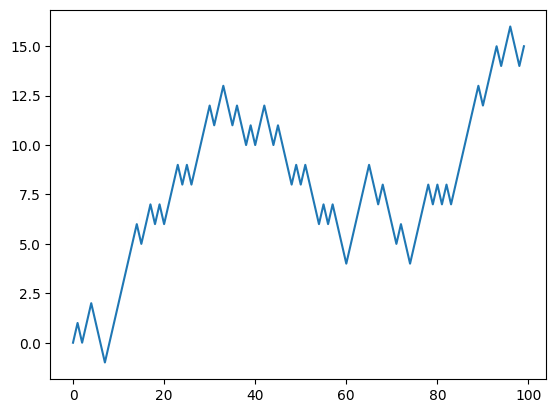

In [81]:
%time

## Python way:
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0,1) else -1 # randint returns either 0 (step = -1) or 1 (step = 1). 
    position += step
    walk.append(position)

plt.plot(walk[:100])
plt.show()

CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 3.1 μs


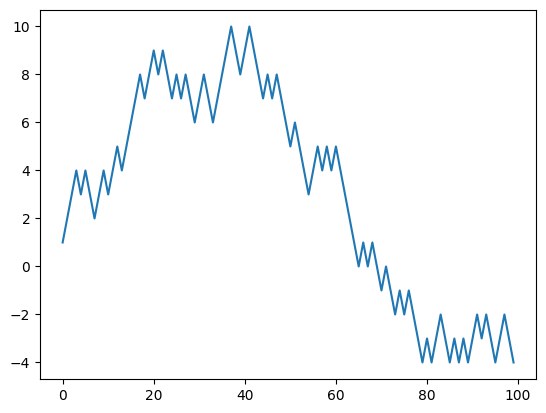

In [82]:
%time
## NumPy way:

nsteps = 1000
draws = np.random.randint(0,2,size=nsteps) # 0 or 1
steps = np.where(draws > 0, 1, -1) 
walk = steps.cumsum() # cumulative sum

plt.plot(walk[:100])
plt.show()

In [92]:
## Statistics of random walks

print(walk.min())
print(walk.max())

### First crossing time at 10
print((walk >= 10).argmax()) # (walk >= 10) returns a boolean array, True is the maximum value, False is the minimum value. argmax returns the index of the first occurrence of the maximum value.

-9
33
37


In [93]:
## Multiple random walks
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0,2,size=(nwalks, nsteps))
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(1)

print(walks.max())
print(walks.min())

117
-107


In [97]:
hits30 = (walks >= 30).any(1) # any(1) returns True if any element in the row is True, otherwise returns False. hits30 is a boolean array of shape (nwalks,). True if the walk reaches 30, False otherwise.
print(hits30.sum())

1767


In [99]:
crossing_times = (walks[hits30] >= 30).argmax(1) # walks[hits30] select the first index where hits30 is True. 
print(crossing_times.mean()) # mean crossing time for the walks that

503.02263723825695
